# London Housing Case Study - Tier 3 Complete

## Objectives
Hey! Great job getting through those challenging DataCamp courses. You're learning a lot in a short span of time. 

In this notebook, you're going to apply the skills you've been learning, bridging the gap between the controlled environment of DataCamp and the *slightly* messier work that data scientists do with actual datasets!

Here’s the mystery we’re going to solve: ***which boroughs of London have seen the greatest increase in housing prices, on average, over the last two decades?***


A borough is just a fancy word for district. You may be familiar with the five boroughs of New York… well, there are 32 boroughs within Greater London [(here's some info for the curious)](https://en.wikipedia.org/wiki/London_boroughs). Some of them are more desirable areas to live in, and the data will reflect that with a greater rise in housing prices.

***This is the Tier 3 notebook, which means it's not filled in at all: we'll just give you the skeleton of a project, the brief and the data. It's up to you to play around with it and see what you can find out! Good luck! If you struggle, feel free to look at easier tiers for help; but try to dip in and out of them, as the more independent work you do, the better it is for your learning!***

This challenge will make use of only what you learned in the following DataCamp courses: 
- Prework courses (Introduction to Python for Data Science, Intermediate Python for Data Science)
- Data Types for Data Science
- Python Data Science Toolbox (Part One) 
- pandas Foundations
- Manipulating DataFrames with pandas
- Merging DataFrames with pandas

Of the tools, techniques and concepts in the above DataCamp courses, this challenge should require the application of the following: 
- **pandas**
    - **data ingestion and inspection** (pandas Foundations, Module One) 
    - **exploratory data analysis** (pandas Foundations, Module Two)
    - **tidying and cleaning** (Manipulating DataFrames with pandas, Module Three) 
    - **transforming DataFrames** (Manipulating DataFrames with pandas, Module One)
    - **subsetting DataFrames with lists** (Manipulating DataFrames with pandas, Module One) 
    - **filtering DataFrames** (Manipulating DataFrames with pandas, Module One) 
    - **grouping data** (Manipulating DataFrames with pandas, Module Four) 
    - **melting data** (Manipulating DataFrames with pandas, Module Three) 
    - **advanced indexing** (Manipulating DataFrames with pandas, Module Four) 
- **matplotlib** (Intermediate Python for Data Science, Module One)
- **fundamental data types** (Data Types for Data Science, Module One) 
- **dictionaries** (Intermediate Python for Data Science, Module Two)
- **handling dates and times** (Data Types for Data Science, Module Four)
- **function definition** (Python Data Science Toolbox - Part One, Module One)
- **default arguments, variable length, and scope** (Python Data Science Toolbox - Part One, Module Two) 
- **lambda functions and error handling** (Python Data Science Toolbox - Part One, Module Four) 

## The Data Science Pipeline

This is Tier Three, so we'll get you started. But after that, it's all in your hands! When you feel done with your investigations, look back over what you've accomplished, and prepare a quick presentation of your findings for the next mentor meeting. 

Data Science is magical. In this case study, you'll get to apply some complex machine learning algorithms. But as  [David Spiegelhalter](https://www.youtube.com/watch?v=oUs1uvsz0Ok) reminds us, there is no substitute for simply **taking a really, really good look at the data.** Sometimes, this is all we need to answer our question.

Data Science projects generally adhere to the four stages of Data Science Pipeline:
1. Sourcing and loading 
2. Cleaning, transforming, and visualizing 
3. Modeling 
4. Evaluating and concluding 


### 1. Sourcing and Loading 

Any Data Science project kicks off by importing  ***pandas***. The documentation of this wonderful library can be found [here](https://pandas.pydata.org/). As you've seen, pandas is conveniently connected to the [Numpy](http://www.numpy.org/) and [Matplotlib](https://matplotlib.org/) libraries. 

***Hint:*** This part of the data science pipeline will test those skills you acquired in the pandas Foundations course, Module One. 

#### 1.1. Importing Libraries

In [183]:
# Let's import the pandas, numpy libraries as pd, and np respectively. 
import pandas as pd
import numpy as np

# Load the pyplot collection of functions from matplotlib, as plt 
import matplotlib.pyplot as plt

#### 1.2.  Loading the data
Your data comes from the [London Datastore](https://data.london.gov.uk/): a free, open-source data-sharing portal for London-oriented datasets. 

In [184]:
# First, make a variable called url_LondonHousePrices, and assign it the following link, enclosed in quotation-marks as a string:
# https://data.london.gov.uk/download/uk-house-price-index/70ac0766-8902-4eb5-aab5-01951aaed773/UK%20House%20price%20index.xls

from io import BytesIO
import requests

# url_LondonHousePrices = "https://data.london.gov.uk/download/uk-house-price-index/70ac0766-8902-4eb5-aab5-01951aaed773/UK%20House%20price%20index.xls" # This one isn't working 
# url_LondonHousePrices2 = BytesIO(requests.get(url_LondonHousePrices).content) # This one works

# The dataset we're interested in contains the Average prices of the houses, and is actually on a particular sheet of the Excel file. 
# As a result, we need to specify the sheet name in the read_excel() method.
# Put this data into a variable called properties.  
# properties = pd.read_excel(url_LondonHousePrices2, sheet_name='Average price', index_col= None)

# ok so for the duration of this, we'll instead open the excel sheet locally while the url doesn't work
# First we'll assign the path to UK Houseprice index that's in the same folder as this notebook
local_LondonHousePrices = "UK-House-price-index.xlsx"
# Then we put the data into properties
properties = pd.read_excel(local_LondonHousePrices, sheet_name='Average price', index_col=None)

### 2. Cleaning, transforming, and visualizing
This second stage is arguably the most important part of any Data Science project. The first thing to do is take a proper look at the data. Cleaning forms the majority of this stage, and can be done both before or after Transformation.

The end goal of data cleaning is to have tidy data. When data is tidy: 

1. Each variable has a column.
2. Each observation forms a row.

Keep the end goal in mind as you move through this process, every step will take you closer. 



***Hint:*** This part of the data science pipeline should test those skills you acquired in: 
- Intermediate Python for data science, all modules.
- pandas Foundations, all modules. 
- Manipulating DataFrames with pandas, all modules.
- Data Types for Data Science, Module Four.
- Python Data Science Toolbox - Part One, all modules

**2.1. Exploring your data** 

Think about your pandas functions for checking out a dataframe. 

In [185]:
print(properties.info())
print(properties.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 49 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Unnamed: 0            372 non-null    datetime64[ns]
 1   City of London        373 non-null    object        
 2   Barking & Dagenham    373 non-null    object        
 3   Barnet                373 non-null    object        
 4   Bexley                373 non-null    object        
 5   Brent                 373 non-null    object        
 6   Bromley               373 non-null    object        
 7   Camden                373 non-null    object        
 8   Croydon               373 non-null    object        
 9   Ealing                373 non-null    object        
 10  Enfield               373 non-null    object        
 11  Greenwich             373 non-null    object        
 12  Hackney               373 non-null    object        
 13  Hammersmith & Fulham

In [186]:
print(properties.head())

  Unnamed: 0 City of London Barking & Dagenham     Barnet     Bexley  \
0        NaT      E09000001          E09000002  E09000003  E09000004   
1 1995-01-01          90347              51870      98948      64956   
2 1995-02-01          81213              52513      98848      64786   
3 1995-03-01          78168              52701      97848      64366   
4 1995-04-01          76172              54618      96273      64276   

       Brent    Bromley     Camden    Croydon     Ealing  ... NORTH WEST  \
0  E09000005  E09000006  E09000007  E09000008  E09000009  ...  E12000002   
1      76880      83082     119775      70118      85469  ...      40907   
2      77651      83068     118365      69908      86551  ...      40877   
3      77644      82856     119131      69666      87067  ...      41351   
4      78668      82525     118948      69562      87933  ...      41195   

  YORKS & THE HUMBER EAST MIDLANDS WEST MIDLANDS EAST OF ENGLAND     LONDON  \
0          E12000003     E12000

**2.2. Cleaning the data**

You might find you need to transpose your dataframe, check out what its row indexes are, and reset the index. You  also might find you need to assign the values of the first row to your column headings  . (Hint: recall the .columns feature of DataFrames, as well as the iloc[] method).

Don't be afraid to use StackOverflow for help  with this.

In [187]:
t_properties = properties.transpose()
# t_properties.head()
# t_properties.index
t_properties = t_properties.reset_index()
print(t_properties.head())

                index          0                    1                    2  \
0          Unnamed: 0        NaT  1995-01-01 00:00:00  1995-02-01 00:00:00   
1      City of London  E09000001                90347                81213   
2  Barking & Dagenham  E09000002                51870                52513   
3              Barnet  E09000003                98948                98848   
4              Bexley  E09000004                64956                64786   

                     3                    4                    5  \
0  1995-03-01 00:00:00  1995-04-01 00:00:00  1995-05-01 00:00:00   
1                78168                76172                83392   
2                52701                54618                54524   
3                97848                96273                95737   
4                64366                64276                63995   

                     6                    7                    8  ...  \
0  1995-06-01 00:00:00  1995-07-01 00:00:00  1995

**2.3. Cleaning the data (part 2)**

You might we have to **rename** a couple columns. How do you do this? The clue's pretty bold...

In [188]:
# This assigns the two columns 
t_properties.iloc[0, 0] = 'Borough'
t_properties.iloc[0, 1] = 'ID'
# This gets the info / column names from row 0 and assingns it
tp_cols = t_properties.iloc[0]
t_properties.columns = tp_cols
# This changes the names of the times in the columns to have ignore the times. We'll do this by getting everything before '  '
t_properties.columns = t_properties.columns.astype(str).str.split(' ').str[0]
print(t_properties.head())

0             Borough         ID           1995-01-01           1995-02-01  \
0             Borough         ID  1995-01-01 00:00:00  1995-02-01 00:00:00   
1      City of London  E09000001                90347                81213   
2  Barking & Dagenham  E09000002                51870                52513   
3              Barnet  E09000003                98948                98848   
4              Bexley  E09000004                64956                64786   

0           1995-03-01           1995-04-01           1995-05-01  \
0  1995-03-01 00:00:00  1995-04-01 00:00:00  1995-05-01 00:00:00   
1                78168                76172                83392   
2                52701                54618                54524   
3                97848                96273                95737   
4                64366                64276                63995   

0           1995-06-01           1995-07-01           1995-08-01  ...  \
0  1995-06-01 00:00:00  1995-07-01 00:00:00  1995

In [189]:
# This drops the first row, which is now redundant
dropped_properties = t_properties.drop(0)
print(dropped_properties.head())

0             Borough         ID 1995-01-01 1995-02-01 1995-03-01 1995-04-01  \
1      City of London  E09000001      90347      81213      78168      76172   
2  Barking & Dagenham  E09000002      51870      52513      52701      54618   
3              Barnet  E09000003      98948      98848      97848      96273   
4              Bexley  E09000004      64956      64786      64366      64276   
5               Brent  E09000005      76880      77651      77644      78668   

0 1995-05-01 1995-06-01 1995-07-01 1995-08-01  ... 2025-03-01 2025-04-01  \
1      83392      93757     108801     110976  ...     730981     749190   
2      54524      55200      53569      53691  ...     365018     363557   
3      95737      95577      96992      97968  ...     611135     610187   
4      63995      64251      63721      64431  ...     403108     395416   
5      79464      80118      79920      79295  ...     560808     559909   

0 2025-05-01 2025-06-01 2025-07-01 2025-08-01 2025-09-01 2025-

**2.4.Transforming the data**

Remember what Wes McKinney said about tidy data? 

You might need to **melt** your DataFrame here. 

In [190]:
# Time to melt the data!
melted_properties = dropped_properties
# This makes it a tidier dataframe, with the date as a variable instead of a column name.
melted_properties = pd.melt(melted_properties, id_vars=['Borough', 'ID'], var_name='Month', value_name='Average Price')
melted_properties['Month'] = pd.to_datetime(melted_properties['Month']) # Month Column becomes Monthtime
# This drops rows with null values in 'Average Price' column 
melted_properties = melted_properties.dropna(subset=['Average Price'])
# This converts the 'Average Price' column to numeric, then to float, so we can do calculations with it.
melted_properties['Average Price'] = pd.to_numeric(melted_properties['Average Price']).astype(float)
print(melted_properties.head())

              Borough         ID      Month  Average Price
0      City of London  E09000001 1995-01-01        90347.0
1  Barking & Dagenham  E09000002 1995-01-01        51870.0
2              Barnet  E09000003 1995-01-01        98948.0
3              Bexley  E09000004 1995-01-01        64956.0
4               Brent  E09000005 1995-01-01        76880.0


Remember to make sure your column data types are all correct. Average prices, for example, should be floating point numbers... 

In [191]:
print(melted_properties.dtypes)

Borough                  object
ID                       object
Month            datetime64[ns]
Average Price           float64
dtype: object


**2.5. Cleaning the data (part 3)**

Do we have an equal number of observations in the ID, Average Price, Month, and London Borough columns? Remember that there are only 32 London Boroughs. How many entries do you have in that column? 

Check out the contents of the London Borough column, and if you find null values, get rid of them however you see fit. 

In [192]:
borough_num = melted_properties['Borough'].nunique()
print(f'There are {borough_num} unique boroughs in the dataset')

num_entries = melted_properties['Borough'].count()
print(f'There are {num_entries} total entries in the dataset')
print(melted_properties.info())

There are 45 unique boroughs in the dataset
There are 16740 total entries in the dataset
<class 'pandas.core.frame.DataFrame'>
Index: 16740 entries, 0 to 17855
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Borough        16740 non-null  object        
 1   ID             16740 non-null  object        
 2   Month          16740 non-null  datetime64[ns]
 3   Average Price  16740 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 653.9+ KB
None


In [193]:
# Unique boroughs in the dataset as of this point
unique_boroughs = melted_properties['Borough'].unique()
print("Unique Boroughs in the dataset: ", unique_boroughs)

# Let's check for duplciates
duplicates = melted_properties.duplicated(subset=['Borough', 'ID', 'Month'], keep=False)
num_duplicates = duplicates.sum()
print(f'There are {num_duplicates} duplicate entries in the dataset')

Unique Boroughs in the dataset:  ['City of London' 'Barking & Dagenham' 'Barnet' 'Bexley' 'Brent' 'Bromley'
 'Camden' 'Croydon' 'Ealing' 'Enfield' 'Greenwich' 'Hackney'
 'Hammersmith & Fulham' 'Haringey' 'Harrow' 'Havering' 'Hillingdon'
 'Hounslow' 'Islington' 'Kensington & Chelsea' 'Kingston upon Thames'
 'Lambeth' 'Lewisham' 'Merton' 'Newham' 'Redbridge' 'Richmond upon Thames'
 'Southwark' 'Sutton' 'Tower Hamlets' 'Waltham Forest' 'Wandsworth'
 'Westminster' 'Inner London' 'Outer London' 'NORTH EAST' 'NORTH WEST'
 'YORKS & THE HUMBER' 'EAST MIDLANDS' 'WEST MIDLANDS' 'EAST OF ENGLAND'
 'LONDON' 'SOUTH EAST' 'SOUTH WEST' 'England']
There are 0 duplicate entries in the dataset


In [194]:
# So there's more boroughs than there should be, but no duplicates. Wack. Here's a list of boroughs that are real and in London
borough_list = ['City of London', 'Barking & Dagenham', 'Barnet', 'Bexley', 'Brent', 'Bromley',
    'Camden', 'Croydon', 'Ealing', 'Enfield', 'Greenwich', 'Hackney',
    'Hammersmith & Fulham', 'Haringey', 'Harrow', 'Havering', 'Hillingdon',
    'Hounslow', 'Islington', 'Kensington & Chelsea', 'Kingston upon Thames',
    'Lambeth', 'Lewisham', 'Merton', 'Newham', 'Redbridge', 'Richmond upon Thames',
    'Southwark', 'Sutton', 'Tower Hamlets', 'Waltham Forest', 'Wandsworth',
    'Westminster']
# Let's filter out the boroughs that aren't in the list of boroughs above
boroughs_filtered = melted_properties[melted_properties['Borough'].isin(borough_list)]
print(boroughs_filtered.head(34))
print("Unique number of boroughs after filtering: ", boroughs_filtered['Borough'].nunique())

                 Borough         ID      Month  Average Price
0         City of London  E09000001 1995-01-01        90347.0
1     Barking & Dagenham  E09000002 1995-01-01        51870.0
2                 Barnet  E09000003 1995-01-01        98948.0
3                 Bexley  E09000004 1995-01-01        64956.0
4                  Brent  E09000005 1995-01-01        76880.0
5                Bromley  E09000006 1995-01-01        83082.0
6                 Camden  E09000007 1995-01-01       119775.0
7                Croydon  E09000008 1995-01-01        70118.0
8                 Ealing  E09000009 1995-01-01        85469.0
9                Enfield  E09000010 1995-01-01        77018.0
10             Greenwich  E09000011 1995-01-01        65784.0
11               Hackney  E09000012 1995-01-01        63375.0
12  Hammersmith & Fulham  E09000013 1995-01-01       129363.0
13              Haringey  E09000014 1995-01-01        81997.0
14                Harrow  E09000015 1995-01-01        86737.0
15      

**2.6. Visualizing the data**

To visualize the data, why not subset on a particular London Borough? Maybe do a line plot of Month against Average Price?

In [195]:
# Let's see how many entries there are for each borough
# borough_counts = boroughs_filtered['Borough'].value_counts()
# print(borough_counts) # This revealed like 372 entries for each borough, so we can choose any

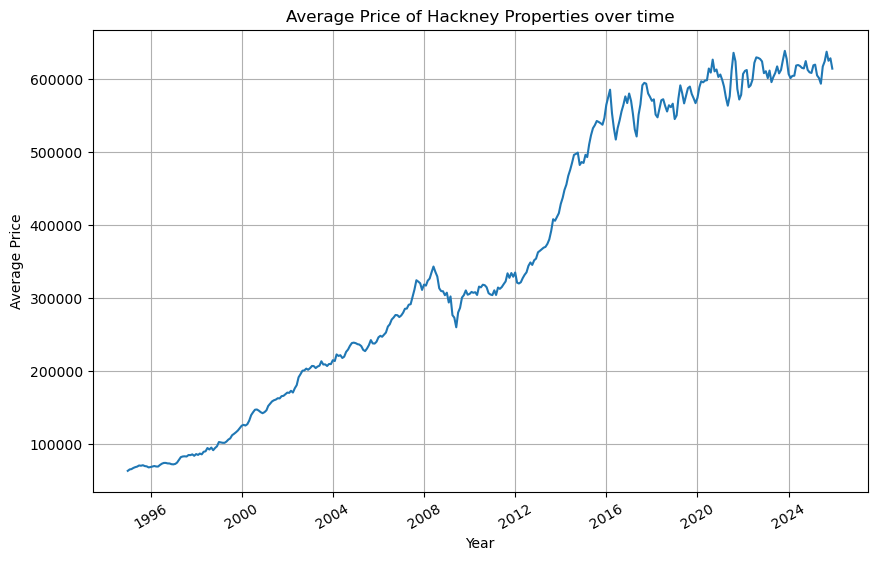

In [196]:
# So we need the data for one borough first
hackney_data = boroughs_filtered[boroughs_filtered['Borough'] == 'Hackney']

# We'll do a line plot of Month against average price (month really is Year in this case, as checked after 1st time doing this)
plt.figure(figsize=(10, 6))
plt.plot(hackney_data['Month'], hackney_data['Average Price'])
plt.xlabel('Year')
plt.ylabel('Average Price')
plt.title('Average Price of Hackney Properties over time')
plt.xticks(rotation=30)
plt.grid(True)
plt.show()

To limit the number of data points you have, you might want to extract the year from every month value your *Month* column. 

To this end, you *could* apply a ***lambda function***. Your logic could work as follows:
1. look through the `Month` column
2. extract the year from each individual value in that column 
3. store that corresponding year as separate column. 

Whether you go ahead with this is up to you. Just so long as you answer our initial brief: which boroughs of London have seen the greatest house price increase, on average, over the past two decades? 

In [197]:
# First let's make a 'Year' column by extracting from the 'Month' column
boroughs_filtered['Year'] = boroughs_filtered['Month'].dt.year
print(boroughs_filtered.head())

              Borough         ID      Month  Average Price  Year
0      City of London  E09000001 1995-01-01        90347.0  1995
1  Barking & Dagenham  E09000002 1995-01-01        51870.0  1995
2              Barnet  E09000003 1995-01-01        98948.0  1995
3              Bexley  E09000004 1995-01-01        64956.0  1995
4               Brent  E09000005 1995-01-01        76880.0  1995


/var/folders/b6/8b3dnv_j3xx1xvng7gsm8rl80000gq/T/ipykernel_9129/2783417509.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  boroughs_filtered['Year'] = boroughs_filtered['Month'].dt.year


In [208]:
# Ok so this is a function that takes in a list of boroughs (strings) and prints out the plot of average price over time
def plot_boroughs(borough_list):
    plt.clf()
    plt.figure(figsize=(12, 8))
    for borough in borough_list:
        borough_data = boroughs_filtered[boroughs_filtered['Borough'] == borough]
        plt.plot(borough_data['Year'], borough_data['Average Price'], label=borough)
    plt.xlabel('Year')
    plt.ylabel('Average Price')
    plt.title('Average Price of Properties over time by Borough')
    plt.xticks(rotation=30)
    plt.grid(True)
    plt.legend()
    plt.show()

<Figure size 640x480 with 0 Axes>

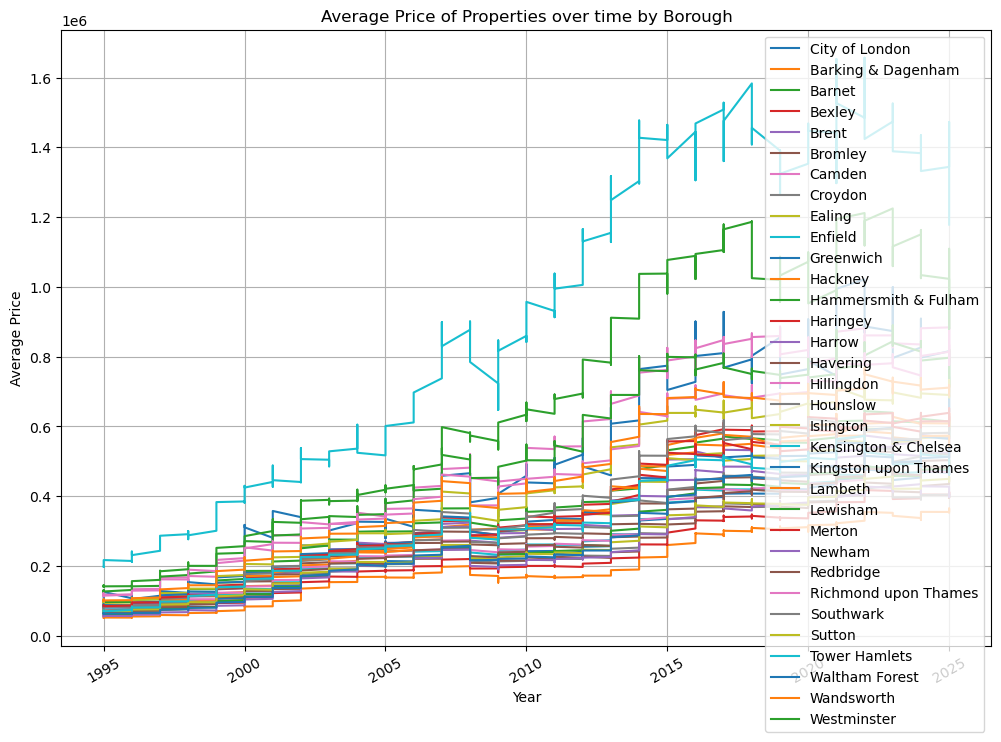

In [209]:
# Time to do the same for all the boroughs
plot_boroughs(borough_list)

[['City of London', 'Barking & Dagenham', 'Barnet', 'Bexley', 'Brent', 'Bromley'], ['Camden', 'Croydon', 'Ealing', 'Enfield', 'Greenwich', 'Hackney'], ['Hammersmith & Fulham', 'Haringey', 'Harrow', 'Havering', 'Hillingdon', 'Hounslow'], ['Islington', 'Kensington & Chelsea', 'Kingston upon Thames', 'Lambeth', 'Lewisham', 'Merton'], ['Newham', 'Redbridge', 'Richmond upon Thames', 'Southwark', 'Sutton', 'Tower Hamlets'], ['Waltham Forest', 'Wandsworth', 'Westminster']]


<Figure size 640x480 with 0 Axes>

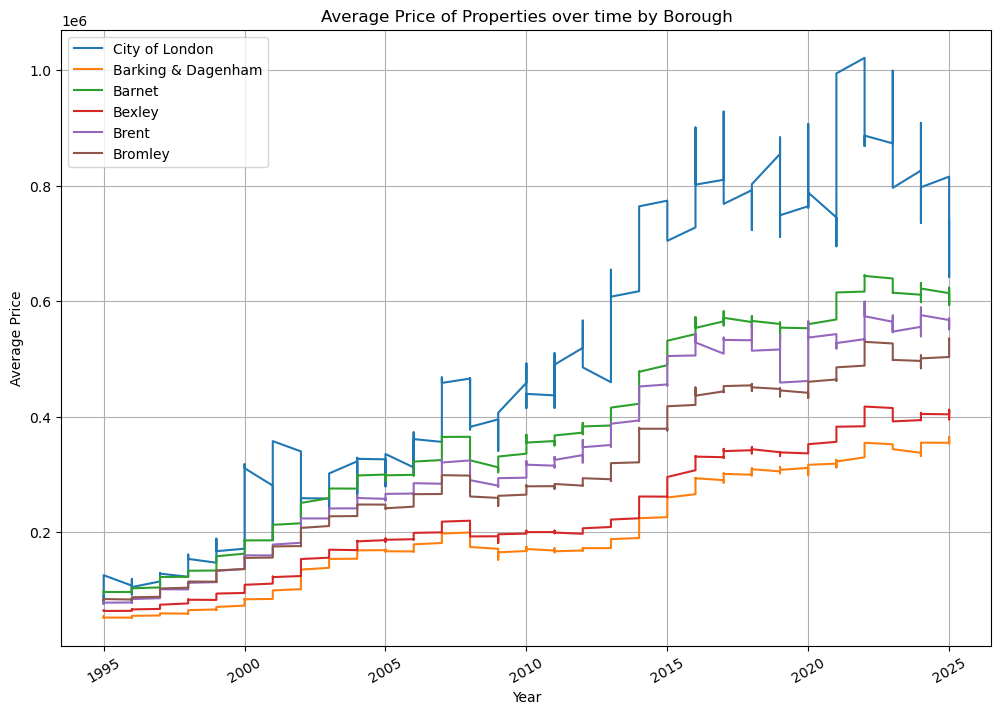

<Figure size 640x480 with 0 Axes>

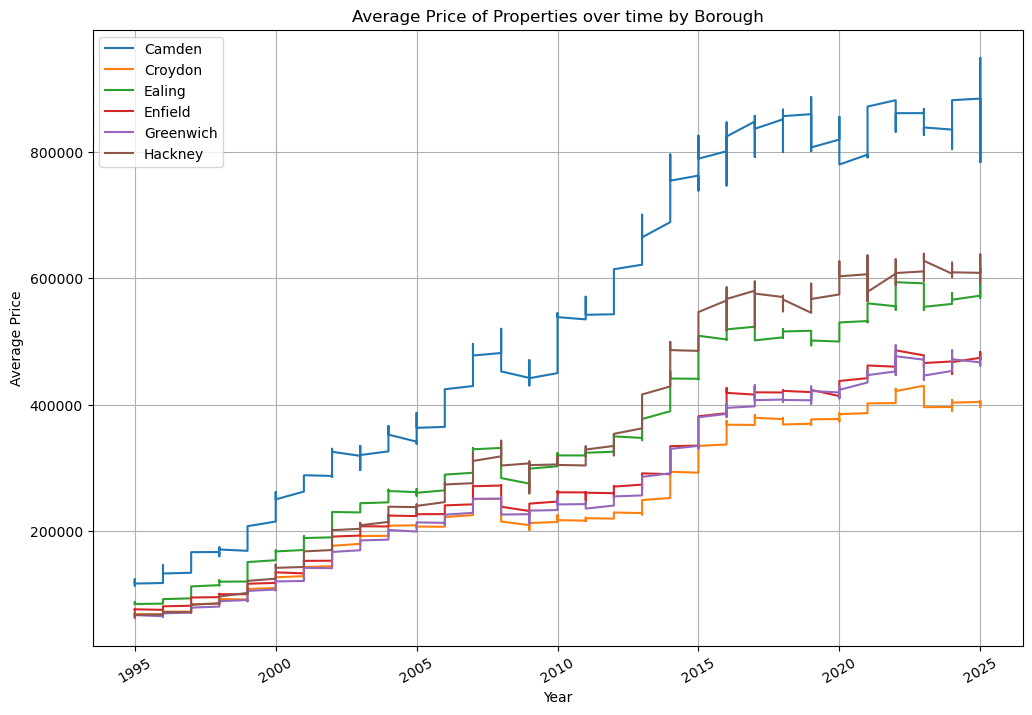

<Figure size 640x480 with 0 Axes>

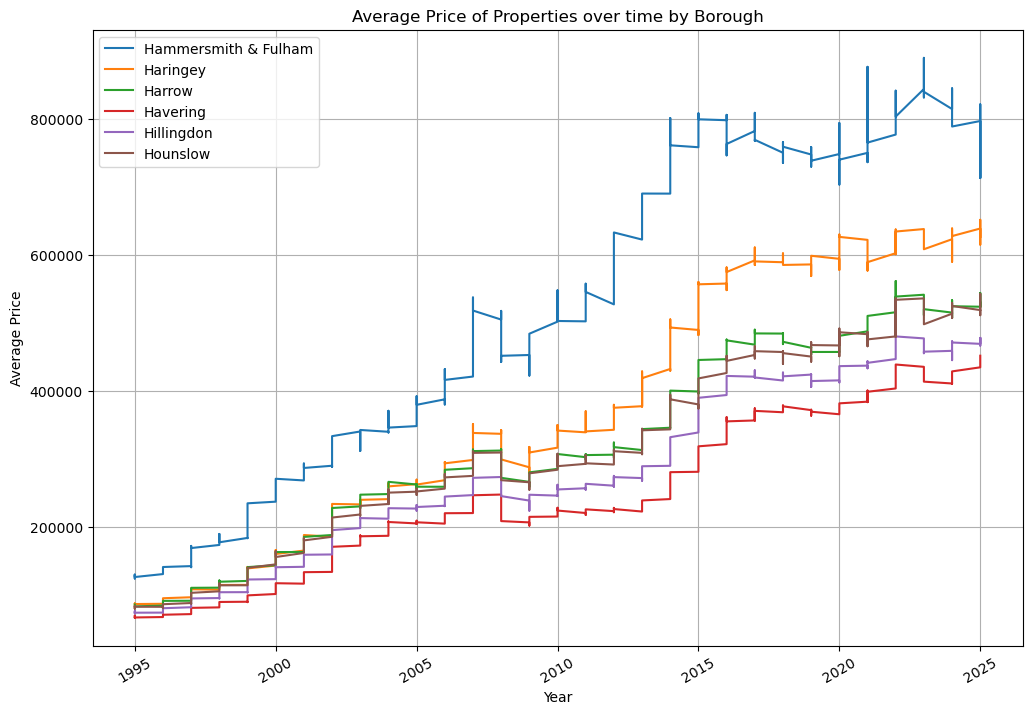

<Figure size 640x480 with 0 Axes>

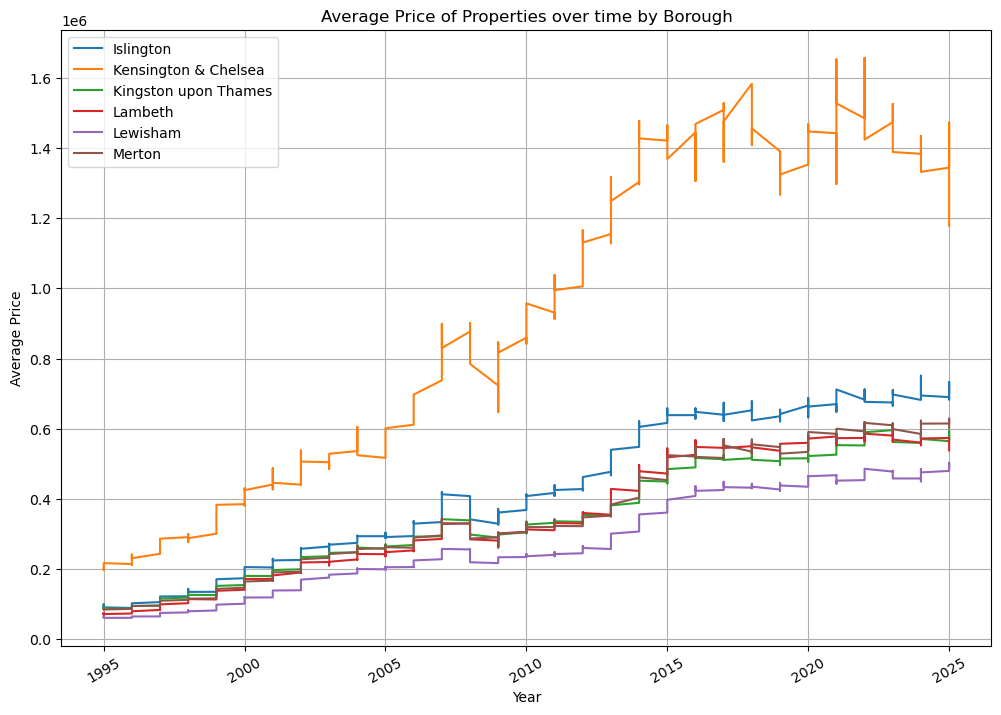

<Figure size 640x480 with 0 Axes>

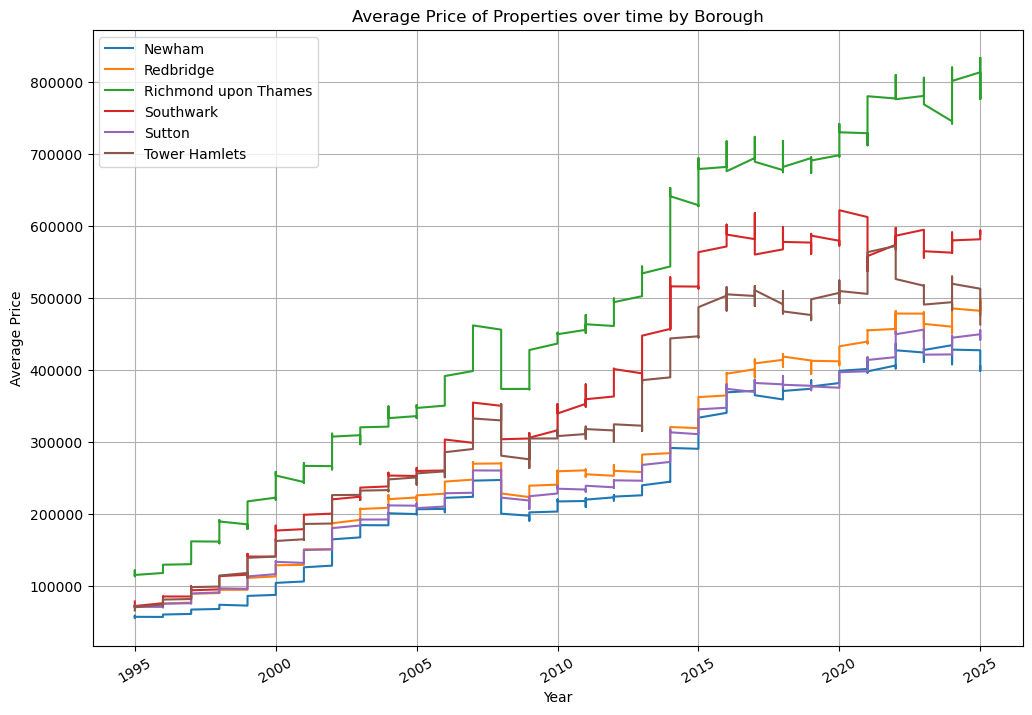

<Figure size 640x480 with 0 Axes>

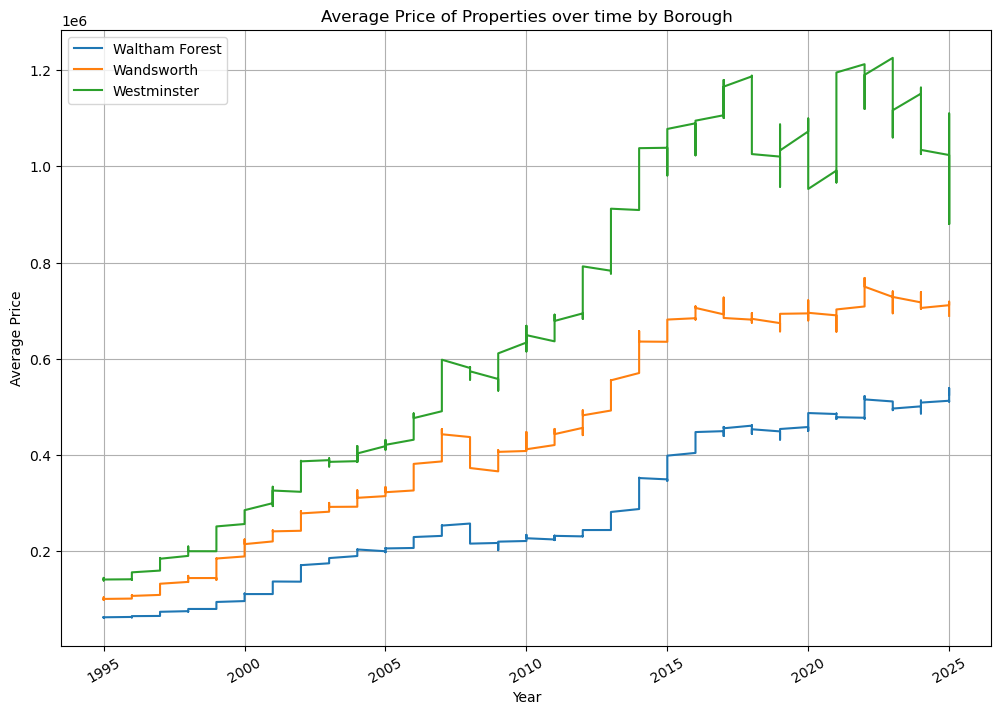

In [210]:
# Ok so after the plot with 33 boroughs, that's too many, so we'll do 6 boroughs at a time instead.
# We'll get an iteration of 6 boroughs at a time 5 times by using a loop
list_iterations = [borough_list[i:i + 6] for i in range(0, len(borough_list), 6)]
print(list_iterations)
# There are 6 lists of boroughs, so we'll do 6 iterations of the plot, one for each list of boroughs
for i in range(len(list_iterations)):
    plot_boroughs(list_iterations[i])

<Figure size 640x480 with 0 Axes>

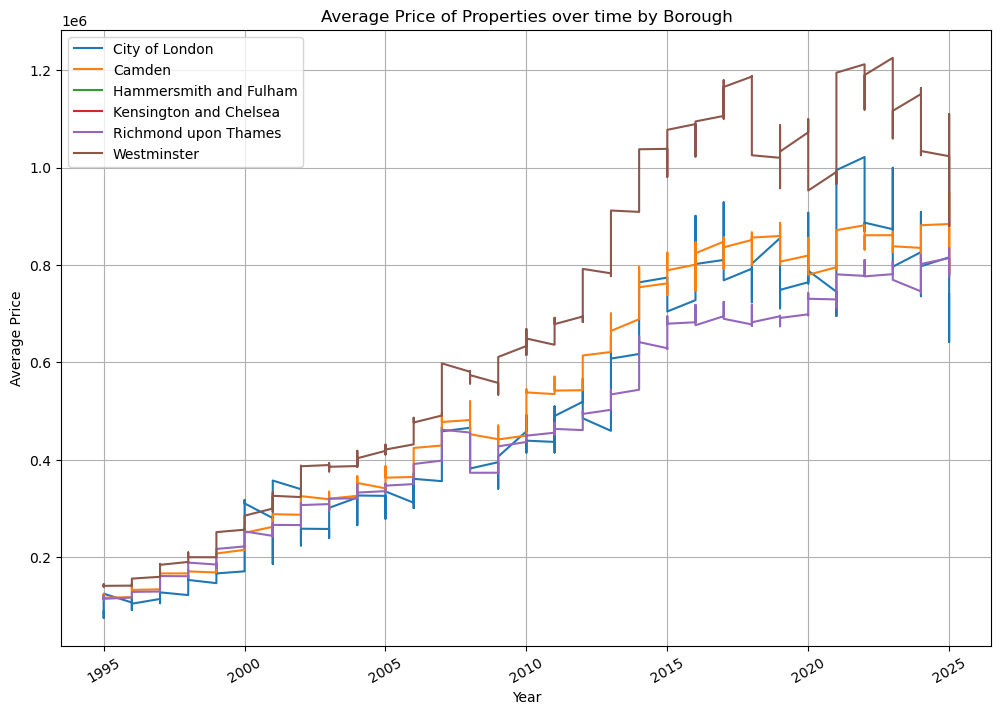

In [212]:
# So we'll make a list with the top borough of each list
b_list_f = ['City of London', 'Camden', 'Hammersmith and Fulham', 'Kensington and Chelsea', 'Richmond upon Thames', 'Westminster']
plot_boroughs(b_list_f)

In [213]:
# This is helpful, but I also want to see the percentage increase in house prices over time
# Grouping the data by borough and year, calculating the average price for each group
avg_prices = boroughs_filtered.groupby(['Borough', 'Year'])['Average Price'].mean().reset_index()

# Getting percentage increase in house prices
avg_prices['Percentage Increase'] = avg_prices.groupby('Borough')['Average Price'].pct_change(periods=20) * 100

# Sort the data by percentage increase in descending order
avg_prices_sorted = avg_prices.sort_values(by='Percentage Increase', ascending=False)

print(avg_prices_sorted.head(10))

             Borough  Year  Average Price  Percentage Increase
362          Hackney  2016   5.559825e+05           676.555254
207   City of London  2016   8.084582e+05           674.544726
361          Hackney  2015   5.239857e+05           667.591798
206   City of London  2015   7.510951e+05           667.273688
857        Southwark  2015   5.400291e+05           628.085743
858        Southwark  2016   5.890422e+05           627.824416
208   City of London  2017   8.395089e+05           625.575434
1012     Westminster  2015   1.025498e+06           621.555905
1013     Westminster  2016   1.058347e+06           615.247182
672          Lambeth  2016   5.508481e+05           610.287503


**3. Modeling**

Consider creating a function that will calculate a ratio of house prices, comparing the price of a house in 2018 to the price in 1998.

Consider calling this function create_price_ratio.

You'd want this function to:
1. Take a filter of dfg, specifically where this filter constrains the London_Borough, as an argument. For example, one admissible argument should be: dfg[dfg['London_Borough']=='Camden'].
2. Get the Average Price for that Borough, for the years 1998 and 2018.
4. Calculate the ratio of the Average Price for 1998 divided by the Average Price for 2018.
5. Return that ratio.

Once you've written this function, you ultimately want to use it to iterate through all the unique London_Boroughs and work out the ratio capturing the difference of house prices between 1998 and 2018.

Bear in mind: you don't have to write a function like this if you don't want to. If you can solve the brief otherwise, then great! 

***Hint***: This section should test the skills you acquired in:
- Python Data Science Toolbox - Part One, all modules

In [216]:
def create_price_ratio(filtered_df):
    # Get average price for years 1998 and 2018
    avg_price_1998 = filtered_df[filtered_df['Year'] == 1998]['Average Price'].mean()
    avg_price_2018 = filtered_df[filtered_df['Year'] == 2018]['Average Price'].mean()
    # Calculate the price ratio
    price_ratio = (avg_price_1998 / avg_price_2018) * 100
    return price_ratio

In [217]:
price_ratios = {} # This will store the price ratios for each borough

for borough in borough_list:
    # Gets the filter for the current borough
    filtered_borough = boroughs_filtered[boroughs_filtered['Borough'] == borough]
    # Calculates the price ratio and stores it in the dictionary
    price_ratios[borough] = create_price_ratio(filtered_borough)

# Convert the dictionary to a DataFrame for easier visuals and sort it
price_ratios_df = pd.DataFrame(price_ratios.items(), columns=['Borough', 'Price Ratio'])
price_ratios_df = price_ratios_df.sort_values(by='Price Ratio', ascending=False)
print(price_ratios_df)

                 Borough  Price Ratio
17              Hounslow    25.144095
26  Richmond upon Thames    24.982769
14                Harrow    24.635696
5                Bromley    24.420952
28                Sutton    24.278455
12  Hammersmith & Fulham    24.160771
16            Hillingdon    23.807906
7                Croydon    23.803911
3                 Bexley    23.530347
9                Enfield    23.459077
20  Kingston upon Thames    23.418985
8                 Ealing    23.192306
15              Havering    23.116747
2                 Barnet    22.947456
25             Redbridge    22.370449
29         Tower Hamlets    21.613518
23                Merton    21.074128
31            Wandsworth    21.019118
10             Greenwich    20.992657
18             Islington    20.653153
4                  Brent    20.427095
1     Barking & Dagenham    20.423086
6                 Camden    20.267356
21               Lambeth    20.168618
19  Kensington & Chelsea    19.676620
13          

### 4. Conclusion
What can you conclude? Type out your conclusion below. 

Look back at your notebook. Think about how you might summarize what you have done, and prepare a quick presentation on it to your mentor at your next meeting. 

We hope you enjoyed this practical project. It should have consolidated your data hygiene and pandas skills by looking at a real-world problem involving just the kind of dataset you might encounter as a budding data scientist. Congratulations, and looking forward to seeing you at the next step in the course! 

Westminister seems to have the one of the highest average prices of properties ofr the boroughs.
Hackney, the City of London, and Southwork are the top 3 boroughs with the highest increase in house prices.

After calculating the price ratio for each London borough by comparing the average house price in 1998 to the one in 2018, the boroughs that saw the greatest increase in house prices are Hackney (16.13%), Waltham Forest (17.13%), and Southwark (18.12%). The boroughs that saw the smallest increase in house prices are Hounslow (25.14%), Richmond upon Thames (24.98%), and Harrow (24.64%). 
The analysis highlights variation in house price increases across different London boroughs over the past 2 decades. The info in this can be valuable for stakeholders who are making informed decisions in the property market in London.